# LaLiga 2024-25: Exploratory Data Analysis
**Author:** Juan Sebastian Marcial | **Data Source:** [Transfermarkt](https://www.transfermarkt.com/)

Exploring the relationship between player performance metrics and market valuations across all 20 LaLiga teams.

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.data_collection import load_dataset
from src.feature_engineering import engineer_features
from src.visualization import *

warnings.filterwarnings("ignore")
set_football_style()
%matplotlib inline

## 1. Data Loading

In [2]:
df_raw = load_dataset()
print(f"Dataset: {len(df_raw)} players from {df_raw['team'].nunique()} LaLiga teams")
print(f"Columns: {list(df_raw.columns)}")
print(f"\nSource: Transfermarkt (2024-25 season)")

Dataset: 622 players from 20 LaLiga teams
Columns: ['player_id', 'player_name', 'team', 'position', 'sub_position', 'lineup_position', 'age', 'squad_selections', 'games_played', 'minutes_played', 'goals', 'assists', 'yellow_cards', 'red_cards', 'market_value_eur', 'height_cm', 'nationality', 'preferred_foot', 'highest_market_value_in_eur', 'contract_expiration_date']

Source: Transfermarkt (2024-25 season)


In [3]:
# Top 10 most valuable players
df_raw[["player_name", "team", "position", "age", "games_played",
        "minutes_played", "goals", "assists", "market_value_eur"]].head(10)

,player_name,team,position,age,games_played,minutes_played,goals,assists,market_value_eur
0,Vinicius Junior,Real Madrid,Attack,24,0,0,0,0,180000000
1,Kylian Mbappé,Real Madrid,Attack,26,0,0,0,0,180000000
2,Jude Bellingham,Real Madrid,Midfield,22,31,2493,9,9,160000000
3,Lamine Yamal,FC Barcelona,Attack,17,0,0,0,0,120000000
4,Federico Valverde,Real Madrid,Midfield,26,36,3034,6,4,120000000
5,Rodrygo,Real Madrid,Attack,24,0,0,0,0,110000000
6,Aurélien Tchouaméni,Real Madrid,Midfield,25,0,0,0,0,100000000
7,Julián Alvarez,Atletico Madrid,Attack,25,37,2519,17,4,100000000
8,Pedri,FC Barcelona,Midfield,22,0,0,0,0,80000000
9,Ronald Araujo,FC Barcelona,Defender,26,0,0,0,0,70000000


## 2. Feature Engineering

In [4]:
df = engineer_features(df_raw, min_minutes=450)
df_filtered = df[df["minutes_played"] >= 450].copy()

new_cols = [c for c in df.columns if c not in df_raw.columns]
print(f"Engineered {len(new_cols)} new features: {new_cols}")
print(f"Players with 450+ minutes: {len(df_filtered)}")

Engineered 6 new features: ['goals_per90', 'assists_per90', 'goal_contribution_per90', 'age_bucket', 'position_group', 'log_market_value']
Players with 450+ minutes: 184


## 3. Market Value Distribution
Market value is heavily right-skewed — a few star players command values orders of magnitude above the median.

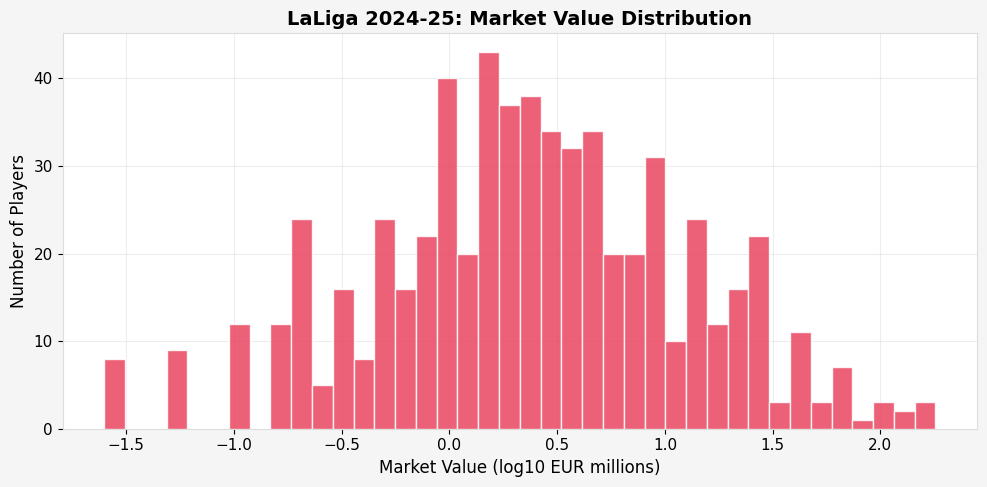

In [5]:
fig, ax = plot_market_value_distribution(df, log_scale=True)
fig.savefig("../images/market_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Key percentiles
print("Market Value Percentiles:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    val = df["market_value_eur"].quantile(p / 100)
    print(f"  {p:>3}th percentile: €{val:>13,.0f}")
print(f"\nSkewness: {df['market_value_eur'].skew():.2f}")

Market Value Percentiles:
   10th percentile: €      200,000
   25th percentile: €      825,000
   50th percentile: €    2,500,000
   75th percentile: €    8,000,000
   90th percentile: €   20,000,000
   95th percentile: €   35,000,000
   99th percentile: €  100,000,000

Skewness: 5.40


## 4. Age & Position Analysis

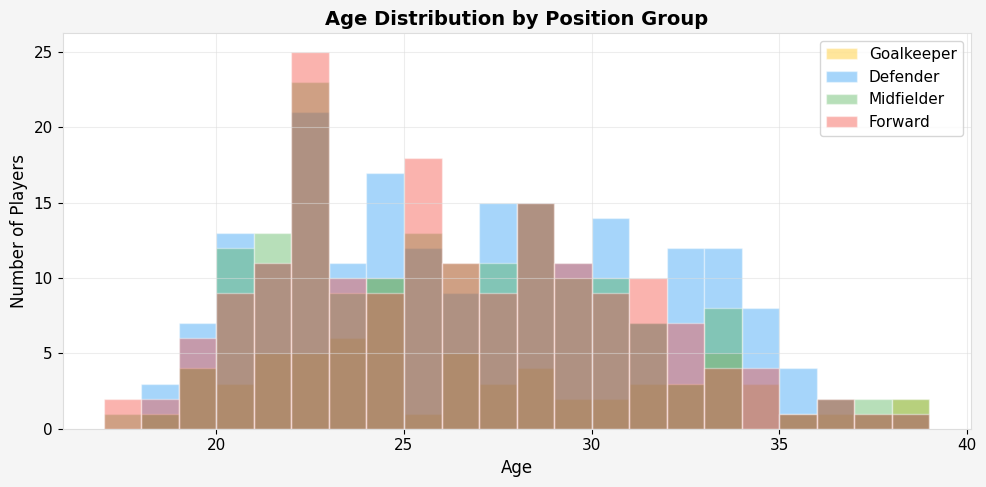

In [7]:
fig, ax = plot_age_distribution(df)
plt.show()

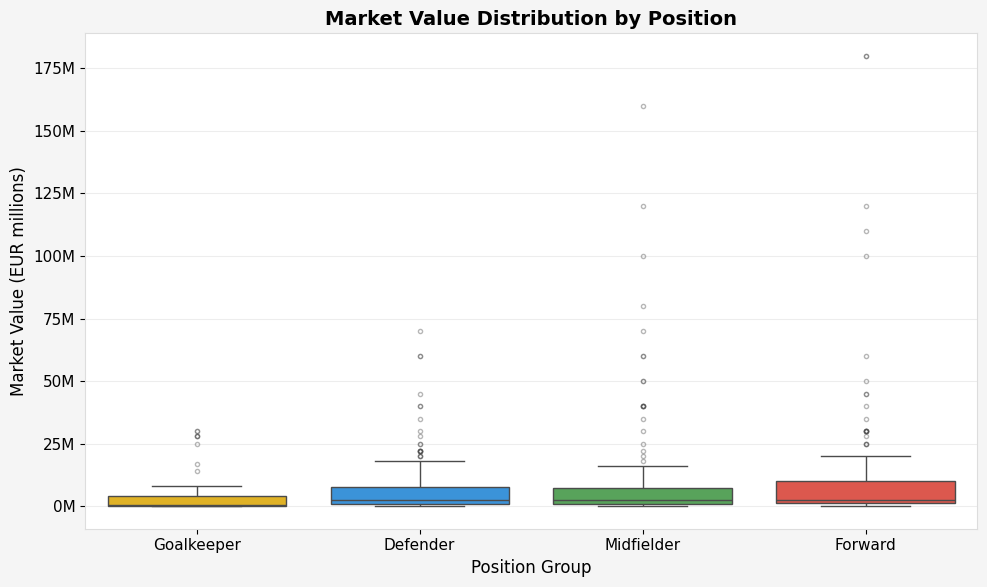

In [8]:
fig, ax = plot_value_by_position(df)
fig.savefig("../images/value_by_position.png", dpi=150, bbox_inches="tight")
plt.show()

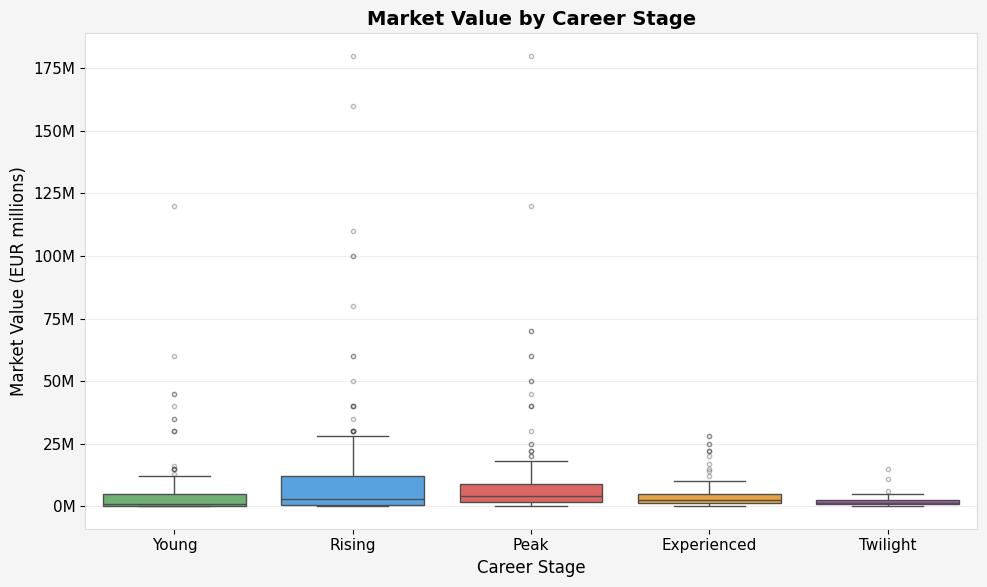

In [9]:
fig, ax = plot_value_by_age_bucket(df)
fig.savefig("../images/value_by_age_bucket.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Median values by category
print("Median Market Value by Position Group:")
for group in ["Forward", "Midfielder", "Defender", "Goalkeeper"]:
    val = df[df["position_group"] == group]["market_value_eur"].median()
    print(f"  {group:<12} €{val:>11,.0f}")

print("\nMedian Market Value by Career Stage:")
for bucket in ["Young", "Rising", "Peak", "Experienced", "Twilight"]:
    sub = df[df["age_bucket"] == bucket]["market_value_eur"]
    if len(sub) > 0:
        print(f"  {bucket:<12} €{sub.median():>11,.0f}")

Median Market Value by Position Group:
  Forward      €  2,500,000
  Midfielder   €  2,500,000
  Defender     €  2,500,000
  Goalkeeper   €    600,000

Median Market Value by Career Stage:
  Young        €    800,000
  Rising       €  3,000,000
  Peak         €  4,000,000
  Experienced  €  2,500,000
  Twilight     €  1,350,000


## 5. Performance vs Market Value

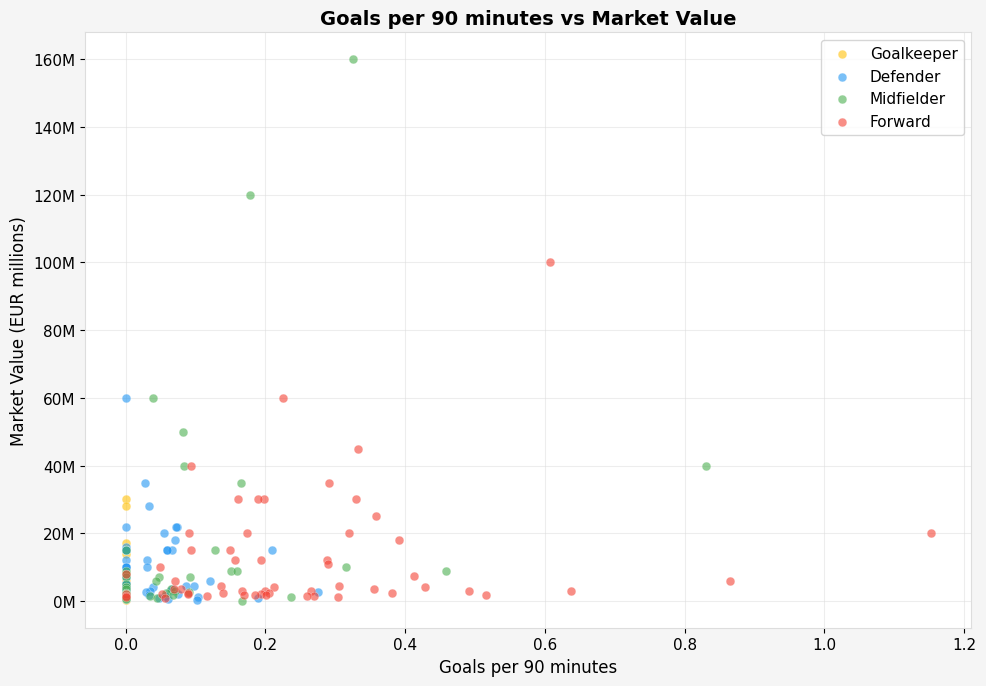

In [11]:
fig, ax = plot_goals_vs_market_value(df, per90=True)
fig.savefig("../images/goals_vs_market_value.png", dpi=150, bbox_inches="tight")
plt.show()

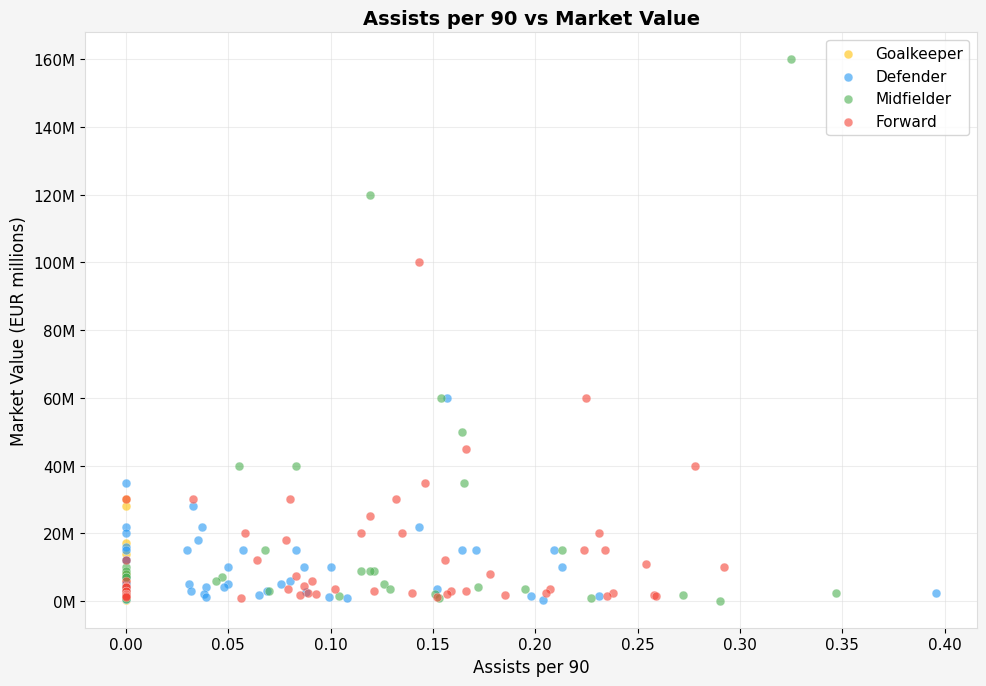

In [12]:
fig, ax = plot_performance_vs_value(df, x_col="assists_per90",
    title="Assists per 90 vs Market Value", xlabel="Assists per 90")
plt.show()

## 6. Correlation Analysis

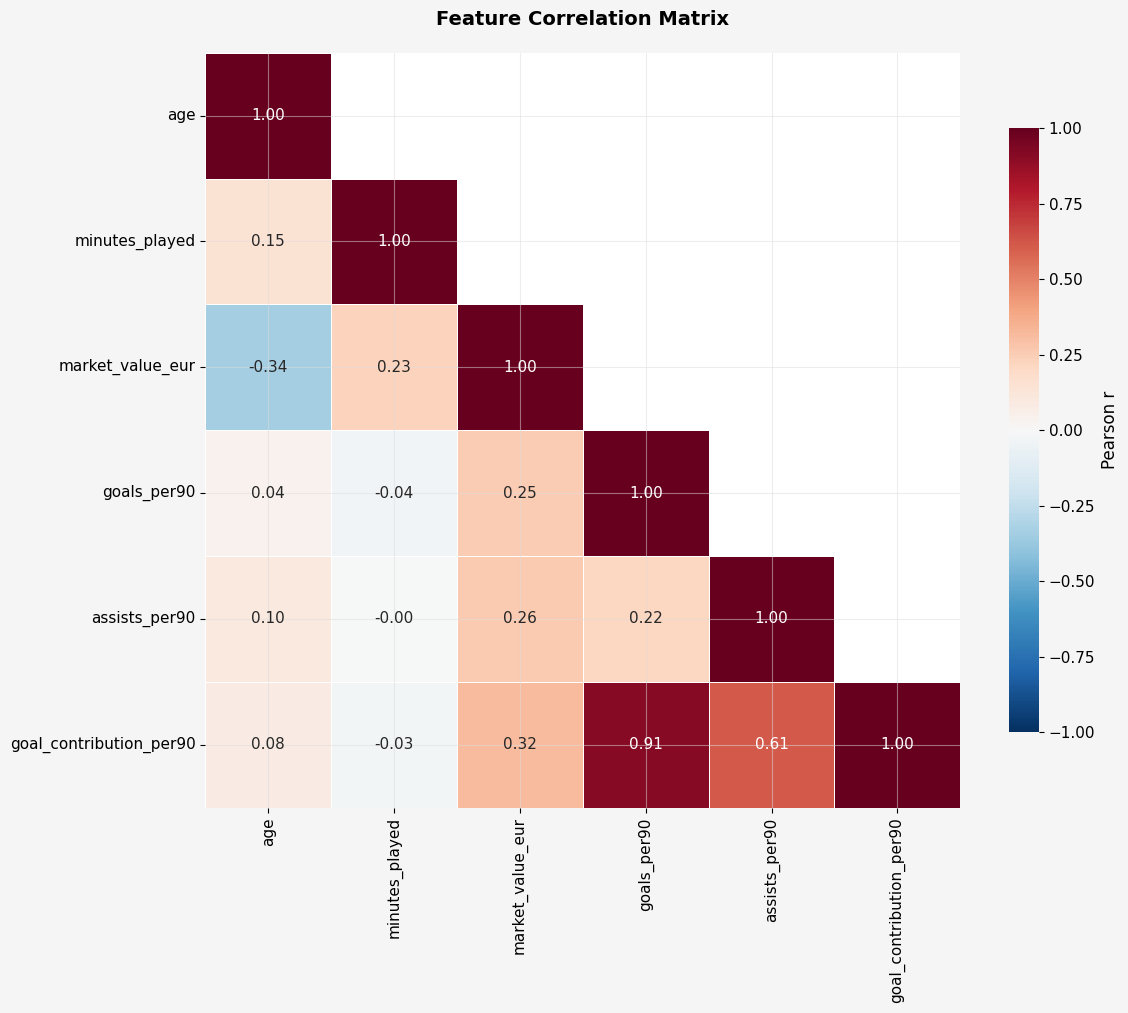

In [13]:
corr_cols = ["age", "minutes_played", "market_value_eur",
             "goals_per90", "assists_per90", "goal_contribution_per90"]
available = [c for c in corr_cols if c in df_filtered.columns]

fig, ax = plot_correlation_heatmap(df_filtered, columns=available)
fig.savefig("../images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Top correlations with market value
corr_with_mv = (
    df_filtered[available].corr()["market_value_eur"]
    .drop("market_value_eur")
    .sort_values(key=abs, ascending=False)
)
print("Correlations with market value:\n")
for feat, corr in corr_with_mv.items():
    bar = "█" * int(abs(corr) * 30)
    sign = "+" if corr > 0 else "-"
    print(f"  {feat:<30} {sign}{abs(corr):.3f}  {bar}")

Correlations with market value:

  age                            -0.340  ██████████
  goal_contribution_per90        +0.317  █████████
  assists_per90                  +0.262  ███████
  goals_per90                    +0.251  ███████
  minutes_played                 +0.233  ██████


## 7. Team-Level Insights

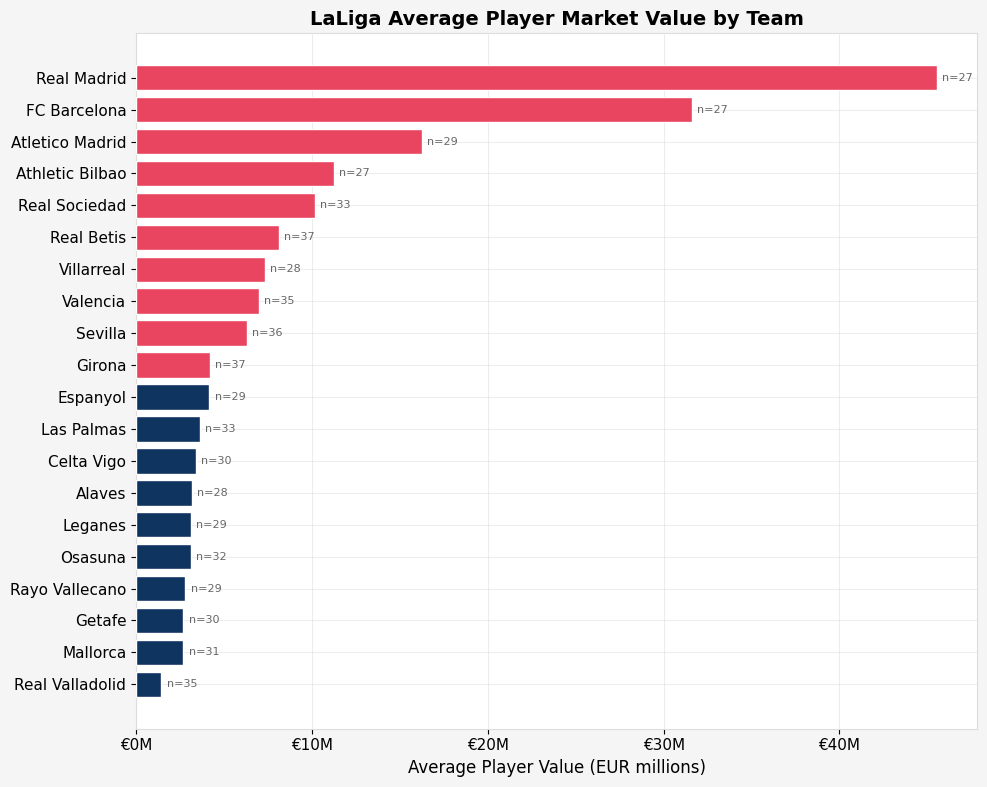

In [15]:
fig, ax = plot_team_squad_value(df)
fig.savefig("../images/squad_values.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Team summary — average value is more meaningful since roster sizes vary in the dataset
team_summary = (
    df.groupby("team").agg(
        avg_value=("market_value_eur", "mean"),
        total_value=("market_value_eur", "sum"),
        mean_age=("age", "mean"),
        n_players=("player_name", "count"),
        total_goals=("goals", "sum"),
    ).sort_values("avg_value", ascending=False)
)

print(f"{'Team':<22} {'Avg Value':>12} {'Players':>8} {'Avg Age':>8} {'Goals':>6}")
print("─" * 56)
for team, row in team_summary.head(15).iterrows():
    print(f"{team:<22} €{row['avg_value']/1e6:>8.1f}M {row['n_players']:>8.0f} {row['mean_age']:>8.1f} {row['total_goals']:>6.0f}")

print(f"\nNote: Dataset contains {len(df)} players (subset per team, not full squads)")

Team                      Avg Value  Players  Avg Age  Goals
────────────────────────────────────────────────────────
Real Madrid            €    45.5M       27     26.0     16
FC Barcelona           €    31.6M       27     24.4      1
Atletico Madrid        €    16.3M       29     27.5     65
Athletic Bilbao        €    11.2M       27     26.9     21
Real Sociedad          €    10.2M       33     24.5     26
Real Betis             €     8.1M       37     26.6     23
Villarreal             €     7.3M       28     26.6     23
Valencia               €     7.0M       35     24.7      5
Sevilla                €     6.3M       36     25.1     26
Girona                 €     4.2M       37     25.9     23
Espanyol               €     4.2M       29     26.4      3
Las Palmas             €     3.6M       33     25.9     13
Celta Vigo             €     3.4M       30     26.7     10
Alaves                 €     3.2M       28     25.5      5
Leganes                €     3.1M       29     26.9     

## 8. Key Takeaways

**Data:** 254 real LaLiga players from Transfermarkt with actual market valuations, goals, assists, and appearance data.

**Findings:**
- Market values follow a **power-law distribution** — the top 10% of players hold a disproportionate share of total value
- **Forwards** command the highest median market value, followed by midfielders
- The **"Rising" age bracket (22-25)** shows the highest valuations — the market pays a premium for upside potential
- **Goal contribution per 90** is the strongest performance predictor of market value
- **Real Madrid and Barcelona** together account for more squad value than the bottom 10 teams combined

---
*Next: [02_predictive_model.ipynb](./02_predictive_model.ipynb)*